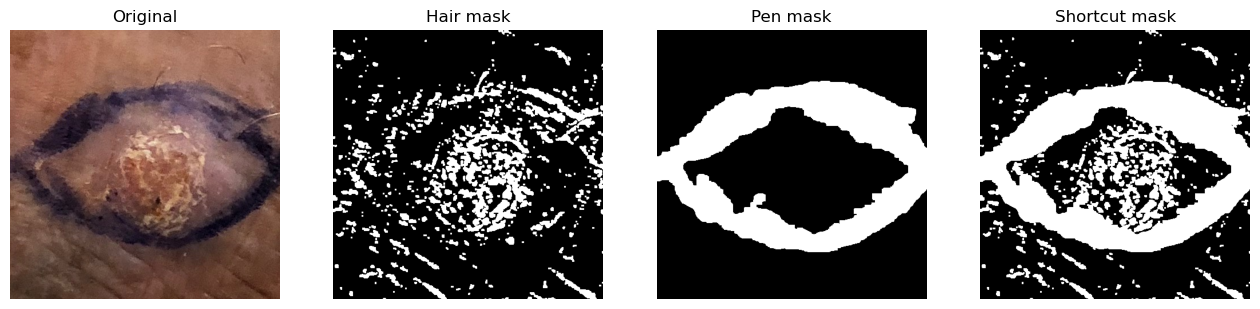

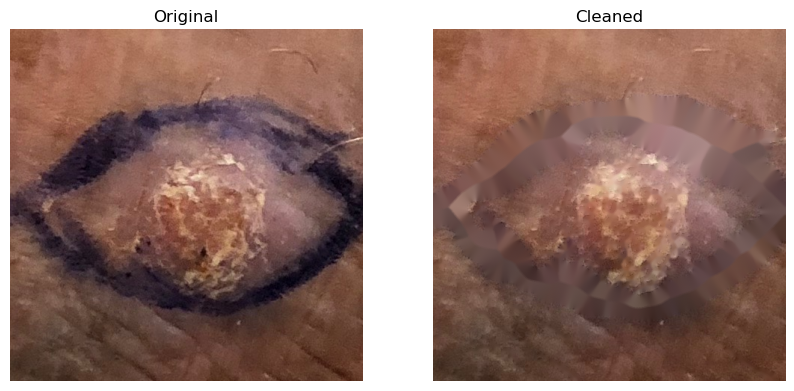

In [132]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "data/imgs/PAT_44_63_151.png"
img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(img_path)

#Pen
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_pen = np.array([95, 25, 20], dtype=np.uint8)
upper_pen = np.array([175, 255, 230], dtype=np.uint8)

pen_mask = cv2.inRange(hsv, lower_pen, upper_pen)

pen_mask = cv2.morphologyEx(
    pen_mask,
    cv2.MORPH_CLOSE,
    np.ones((5, 5), np.uint8))

pen_mask = cv2.dilate(
    pen_mask,
    np.ones((5, 5), np.uint8),
    iterations=2)
# hair
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Smooth a bit first so skin texture is less detected
gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Detect dark thin structures
blackhat_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))
blackhat = cv2.morphologyEx(gray_blur, cv2.MORPH_BLACKHAT, blackhat_kernel)

# Higher threshold = less white noise
_, hair_mask = cv2.threshold(
    blackhat,
    10,
    255,
    cv2.THRESH_BINARY)
# Remove small noisy dots
hair_mask = cv2.morphologyEx(
    hair_mask,
    cv2.MORPH_OPEN,
    np.ones((2, 2), np.uint8))
# Small dilation so detected hairs are covered
hair_mask = cv2.dilate(
    hair_mask,
    np.ones((2, 2), np.uint8),
    iterations=1)
#combined
shortcut_mask = cv2.bitwise_or(hair_mask, pen_mask)

# cleaned image
cleaned_img = cv2.inpaint(
    img,
    shortcut_mask,
    3,
    cv2.INPAINT_TELEA)
#seeing the images and masks
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(hair_mask, cmap="gray")
plt.title("Hair mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(pen_mask, cmap="gray")
plt.title("Pen mask")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(shortcut_mask, cmap="gray")
plt.title("Shortcut mask")
plt.axis("off")

plt.show()

# before and after
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cleaned_img, cv2.COLOR_BGR2RGB))
plt.title("Cleaned")
plt.axis("off")
plt.show()
